In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [2]:
data = {
    "Age": [
        22, 25, 28, 30, 32,
        35, 38, 40, 42, 45,
        48, 50, 52, 55, 58,
        60, 23, 27, 33, 37
    ],

    "Salary": [
        25000, 30000, 32000, 35000, 40000,
        45000, 50000, 55000, 60000, 65000,
        70000, 75000, 80000, 85000, 90000,
        95000, 28000, 33000, 42000, 52000
    ],

    "Purchased": [
        0, 0, 0, 0, 0,
        0, 0, 1, 1, 1,
        1, 1, 1, 1, 1,
        1, 0, 0, 0, 1
    ]
}

df = pd.DataFrame(data)

df.head()

,Age,Salary,Purchased
0,22,25000,0
1,25,30000,0
2,28,32000,0
3,30,35000,0
4,32,40000,0


In [3]:
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
df.describe()

Dataset Shape: (20, 3)

Columns:
Index(['Age', 'Salary', 'Purchased'], dtype='object')

Data Types:
Age          int64
Salary       int64
Purchased    int64
dtype: object

Missing Values:
Age          0
Salary       0
Purchased    0
dtype: int64

Statistical Summary:


,Age,Salary,Purchased
count,20.000000,20.00000,20.000000
mean,39.000000,54350.00000,0.500000
std,11.849939,22108.04807,0.512989
min,22.000000,25000.00000,0.000000
25%,29.500000,34500.00000,0.000000
50%,37.500000,51000.00000,0.500000
75%,48.500000,71250.00000,1.000000
max,60.000000,95000.00000,1.000000


In [4]:
X = df[["Age", "Salary"]]

y = df["Purchased"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   Age  Salary
0   22   25000
1   25   30000
2   28   32000
3   30   35000
4   32   40000

Target:
0    0
1    0
2    0
3    0
4    0
Name: Purchased, dtype: int64


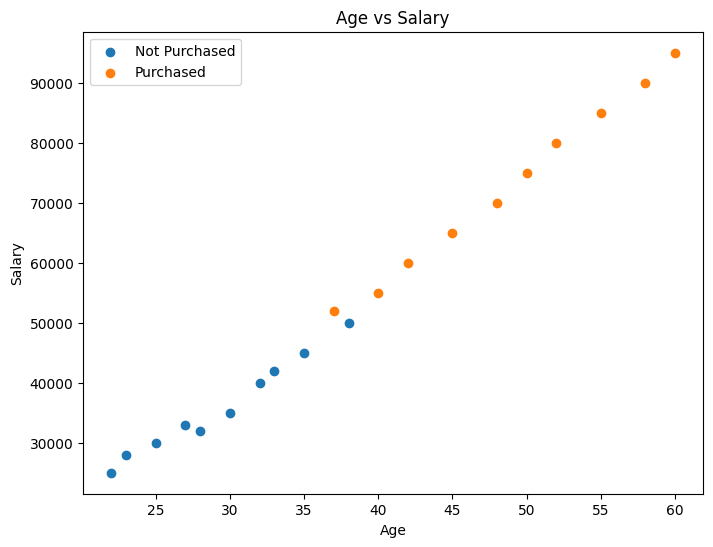

In [5]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df[df["Purchased"] == 0]["Age"],
    df[df["Purchased"] == 0]["Salary"],
    label="Not Purchased"
)

plt.scatter(
    df[df["Purchased"] == 1]["Age"],
    df[df["Purchased"] == 1]["Salary"],
    label="Purchased"
)

plt.xlabel("Age")
plt.ylabel("Salary")
plt.title("Age vs Salary")
plt.legend()

plt.show()

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (16, 2)
Testing Data: (4, 2)


KNN is a distance-based algorithm.

For example:

Age = 30
Salary = 50000

The numerical ranges are very different.

If we don't scale the features, Salary can dominate the distance calculation.

Therefore, scaling is very important for KNN.

In [7]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Scaled Training Data:")
print(X_train_scaled[:5])

Scaled Training Data:
[[-0.43931516 -0.50884015]
 [-0.27195701 -0.37314944]
 [ 0.14643839  0.07915291]
 [ 0.98322917  0.98375762]
 [ 0.31379654  0.30530409]]


In [8]:
knn = KNeighborsClassifier(n_neighbors=3)

knn.fit(X_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=3)

In [9]:
y_pred = knn.predict(X_test_scaled)

print("Predicted Values:")
print(y_pred)

print("\nActual Values:")
print(y_test.values)

Predicted Values:
[1 0 1 1]

Actual Values:
[0 0 1 1]


In [10]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison

,Actual,Predicted
0,0,1
1,0,0
2,1,1
3,1,1


In [12]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 0.75
Accuracy: 75.00%


In [13]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[1 1]
 [0 2]]


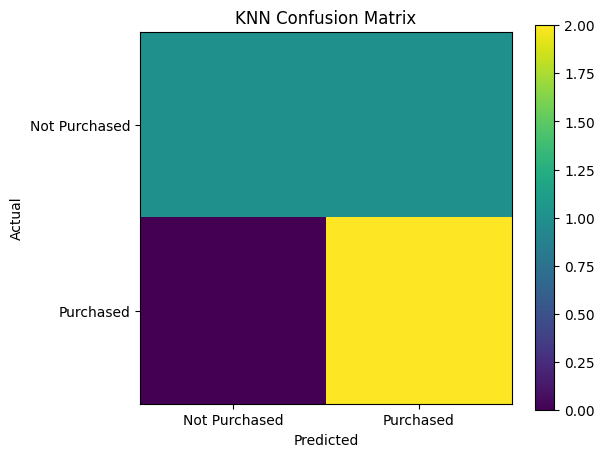

In [14]:
plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.colorbar()

plt.xticks([0, 1], ["Not Purchased", "Purchased"])
plt.yticks([0, 1], ["Not Purchased", "Purchased"])

plt.show()

In [15]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       0.67      1.00      0.80         2

    accuracy                           0.75         4
   macro avg       0.83      0.75      0.73         4
weighted avg       0.83      0.75      0.73         4



In [16]:
k_values = range(1, 11)

accuracies = []

for k in k_values:

    knn = KNeighborsClassifier(n_neighbors=k)

    knn.fit(X_train_scaled, y_train)

    y_pred_k = knn.predict(X_test_scaled)

    accuracy_k = accuracy_score(y_test, y_pred_k)

    accuracies.append(accuracy_k)

C:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreatePro

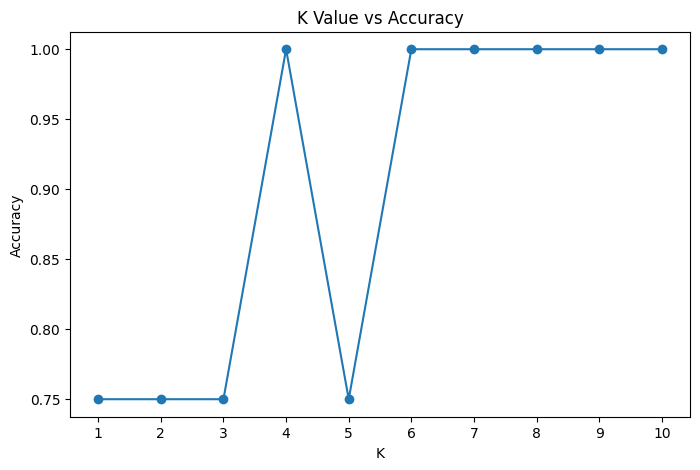

In [17]:
plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    accuracies,
    marker="o"
)

plt.xlabel("K")
plt.ylabel("Accuracy")
plt.title("K Value vs Accuracy")

plt.xticks(list(k_values))

plt.show()

In [18]:
best_k = k_values[np.argmax(accuracies)]

best_accuracy = max(accuracies)

print("Best K:", best_k)
print("Best Accuracy:", best_accuracy)

Best K: 4
Best Accuracy: 1.0


In [19]:
final_knn = KNeighborsClassifier(
    n_neighbors=best_k
)

final_knn.fit(
    X_train_scaled,
    y_train
)

KNeighborsClassifier(n_neighbors=4)

In [20]:
final_predictions = final_knn.predict(X_test_scaled)

final_accuracy = accuracy_score(
    y_test,
    final_predictions
)

print(f"Final Accuracy: {final_accuracy * 100:.2f}%")

Final Accuracy: 100.00%


In [21]:
new_customer = pd.DataFrame({
    "Age": [41],
    "Salary": [62000]
})

new_customer_scaled = scaler.transform(new_customer)

prediction = final_knn.predict(new_customer_scaled)

print("Prediction:", prediction[0])

Prediction: 1


In [22]:
if prediction[0] == 1:
    print("Customer is likely to purchase.")
else:
    print("Customer is unlikely to purchase.")

Customer is likely to purchase.


In [23]:
point_a = np.array([2, 3])
point_b = np.array([5, 7])

distance = np.sqrt(np.sum((point_a - point_b) ** 2))

print("Euclidean Distance:", distance)

Euclidean Distance: 5.0


In [24]:
knn_euclidean = KNeighborsClassifier(
    n_neighbors=5,
    metric="euclidean"
)

In [25]:
knn_manhattan = KNeighborsClassifier(
    n_neighbors=5,
    metric="manhattan"
)

<Figure size 800x600 with 0 Axes>

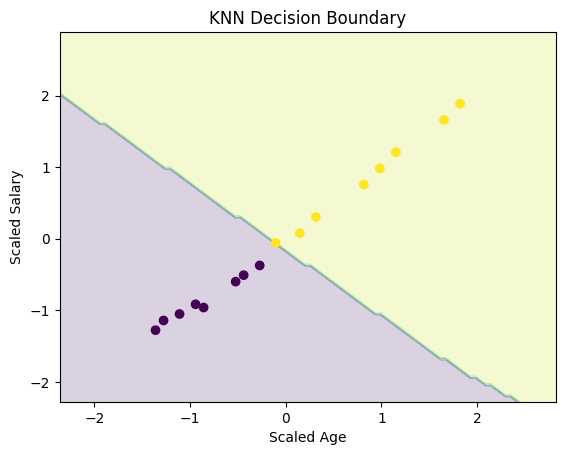

In [26]:
from sklearn.inspection import DecisionBoundaryDisplay

plt.figure(figsize=(8, 6))

DecisionBoundaryDisplay.from_estimator(
    final_knn,
    X_train_scaled,
    response_method="predict",
    alpha=0.2
)

plt.scatter(
    X_train_scaled[:, 0],
    X_train_scaled[:, 1],
    c=y_train
)

plt.xlabel("Scaled Age")
plt.ylabel("Scaled Salary")
plt.title("KNN Decision Boundary")

plt.show()

In [29]:
from sklearn.neighbors import KNeighborsRegressor
X_reg = np.array([
    [1],
    [2],
    [3],
    [4],
    [5]
])

y_reg = np.array([
    10,
    20,
    30,
    40,
    50
])

knn_reg = KNeighborsRegressor(n_neighbors=2)

knn_reg.fit(X_reg, y_reg)

prediction = knn_reg.predict([[3.5]])

print("Prediction:", prediction[0])

Prediction: 35.0


In [30]:
KNeighborsClassifier(
    n_neighbors=5,
    weights="uniform",
    metric="euclidean"
)

KNeighborsClassifier(metric='euclidean')

In [31]:
print("Accuracy:")
print(accuracy_score(y_test, final_predictions))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, final_predictions))

print("\nClassification Report:")
print(classification_report(y_test, final_predictions))

Accuracy:
1.0

Confusion Matrix:
[[2 0]
 [0 2]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4

